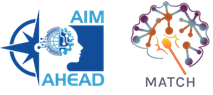

# Generative AI for Biomedical Decisions


Supported by the NIH AIM-AHEAD Data Infrastructure and Capacity Building Program <br><br>
Instructed by Sambit Panda, Ph.D. (University of Texas at San Antonio MATRIX AI Consortium) and Christian Cruz (University of Texas at San Antonio MATRIX AI Consortium) on April 29, 2025. <br>

Slides: https://github.com/qutublab/MATCH/releases/download/Generative-ai-workshop/Generative.AI.for.Biomedical.Decisions.pptx
<br>

Code: https://github.com/qutublab/MATCH/releases/download/Generative-ai-workshop/genai-biomedical-code.ipynb

In [ ]:
import os
import json
import requests

from openai import OpenAI

## Getting Started: Generate Responses with Open AI

The `OpenAI` class creates a Python object that you can then use to generate responses from any of their models. For the most part, other models use a similar API where you call class methods when generating outputs. Prior to running this cell, make sure that you have created a `.env` file containing your `OPENAI_API_KEY`.

In [ ]:
from google.colab import userdata
client = OpenAI(
    # This is the default and can be omitted
    api_key=userdata.get("OPENAI_API_KEY"),
)

Responses are generated using the `create()` method. A [full list of parameters can be found here](https://github.com/openai/openai-python/blob/main/api.md#responses). If you are creating an application, look [using streaming respones](https://platform.openai.com/docs/guides/streaming-responses?api-mode=chat).

In [ ]:
user_prompt = "How do I administer CPR?"

response = client.responses.create(
    model="gpt-4.1-nano",
    input=user_prompt,
)

printmd(response.output_text)

Administering CPR (Cardiopulmonary Resuscitation) can help save someone who is unresponsive and not breathing properly. Here's a step-by-step guide:

**1. Ensure Safety:**  
Make sure the environment is safe for you and the victim.

**2. Check Responsiveness:**  
Gently shake the person and shout, “Are you OK?” If there's no response, proceed.

**3. Call for Help:**  
Call emergency services (911 or your local emergency number). If others are nearby, ask someone to call while you begin CPR.

**4. Check Breathing:**  
Look for normal breathing—chest rising and falling, listening for breath sounds, and feeling for breath on your cheek—within 10 seconds. If the person isn’t breathing or only gasping, start CPR.

**5. Begin Chest Compressions:**  
- Place the heel of one hand on the center of the chest (lower half of the breastbone).  
- Place your other hand on top, interlacing your fingers.  
- Keep your arms straight and shoulders directly above your hands.  
- Push hard and fast—compress the chest at least 2 inches deep at a rate of about 100-120 compressions per minute (the beat of the song "Stayin' Alive" by the Bee Gees is a helpful guide).

**6. Provide Rescue Breaths (if trained and confident):**  
- After 30 compressions, give 2 rescue breaths:  
  - Tilt the person’s head back slightly to open the airway.  
  - Pinch the nose shut.  
  - Cover their mouth with yours to create an airtight seal, and blow in for about 1 second to make the chest rise.  
- If you are not trained or uncomfortable giving rescue breaths, continue with hands-only CPR (compressions only).

**7. Continue CPR:**  
Keep performing cycles of 30 compressions and 2 breaths (or only compressions if not giving breaths) until:  
- Emergency personnel arrive.  
- The person shows signs of life (movement, breathing).  
- You are too exhausted to continue.  
- The scene becomes unsafe.

**Important:**  
- If an Automated External Defibrillator (AED) is available, turn it on and follow the prompts as soon as possible.

**Note:** This is basic guidance; consider taking a certified CPR course for hands-on practice.

You can also get responeses if wish to input an image instead. Take a look at [the OpenAI documentation](https://platform.openai.com/docs/overview) for a full list of all possible use-cases.

In [ ]:
user_prompt = "What is this image"
image_url = "https://upload.wikimedia.org/wikipedia/commons/9/92/EB1911_Heart_-_Thoracic_Viscera.png"

response = client.responses.create(
    model="gpt-4.1-nano",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": user_prompt},
                {"type": "input_image", "image_url": f"{image_url}"},
            ],
        }
    ],
)

printmd(response.output_text)

This image is a detailed anatomical illustration of the human heart and lungs, showing various internal structures and parts. The illustration appears to be from a medical or anatomical textbook, with labels indicating different parts of the heart and respiratory system.

## Customizing Model Responses

### System Instructions

If you take a look at the response from our prompt `How do I administer CPR?`, it seems quite wordy. Also, if I were a professional in the field, I already know a number of these things.  We can simply create a set of system instructions to make the model respond more like we want.

In [ ]:
system_instructions = """
You are an expert emergency physician with decades of experience in CPR. The user is also a clinician.
Keep responses under 100 words.
"""
user_prompt = "How do I administer CPR?"

response = client.responses.create(
    model="gpt-4.1-nano",
    instructions=system_instructions,
    input=user_prompt,
)

printmd(response.output_text)

Ensure scene safety. Check responsiveness and breathing—if unresponsive and not breathing or only gasping, call for help and activate EMS. Place the patient on their back, kneel beside, and perform high-quality CPR:  
- **Chest compressions:** 2 inches deep at 100-120 per minute, allow full recoil  
- **Rescue breaths:** 2 breaths after 30 compressions if trained and comfortable, about 1 second each, watching for chest rise  
Repeat cycle. Use an AED ASAP.

With just a few system instructions, I was able to completely change the model to perform in a much more precise, direct, and concise manner. This is known as **prompt engineering** and can be a very powerful tool for changing model performance. [This guide](https://www.promptingguide.ai/) is a fantastic resource to get started.

### Temperature, Top P

Let's take a look at repeated responses from our model.

In [ ]:
system_instructions = """
You are an expert emergency physician with decades of experience in CPR. The user is also a clinician.
Keep responses under 100 words.
"""
user_prompt = "How do I administer CPR?"

for i in range(3):
    response = client.responses.create(
        model="gpt-4.1-nano",
        instructions=system_instructions,
        input=user_prompt,
    )

    printmd(f"#### Response {i+1} Output:")
    printmd(response.output_text)
    print()

#### Response 1 Output:

Check responsiveness and breathing. Call for emergency help. Begin CPR: 
1. Place hands center of chest, lock elbows, and compress at least 2 inches deep at 100–120/min.
2. Give 30 chest compressions.
3. Open airway (head tilt, chin lift).
4. Provide 2 rescue breaths if trained and comfortable, each lasting about 1 second, watching for chest rise.
Repeat cycle of 30 compressions and 2 breaths. Continue until emergency help arrives or patient recovers.

#### Response 2 Output:

Ensure scene safety, check responsiveness, and call for help. If unresponsive and no breathing or gasping, start CPR. For adults: 30 compressions at 2 inches depth, at 100-120/min, followed by 2 rescue breaths. Compress the center of the chest with straight arms, allowing full recoil. For rescue breaths, tilt the head back, lift the chin, pinch the nose, and give a breath over 1 second, watching for chest rise. Continue until help arrives, the scene becomes unsafe, or the patient shows signs of life.

#### Response 3 Output:

Ensure scene safety, then check for responsiveness. Call emergency services and get an AED. If unresponsive and no pulse, start chest compressions at 100-120/min, pushing hard and fast (about 2 inches deep for adults). Open the airway, give 2 rescue breaths if trained, each lasting 1 second with visible chest rise. Continue cycles of 30 compressions and 2 breaths until help arrives or patient recovers. Use AED as soon as available.

Notice that responses are a little bit different each time. That is because when the model chooses which token to use next, there is a degree of randomness involved. This can be modified by two parameters:

* **Temperature**: This skews the next token distribution towards the most likely token (low) or flattens the distribution (high). The values range from 0 to 2. Low temperatures makes responses more deterministic and high makes responses more creative.
* **Top P**: Only considers top tokens summing to cumulative probability $p$. Values range from 0 to 1. Low top P values focus only on most probable tokens while high focusses on all possible tokens.

It is generally recommended to choose either temperature or top P when controlling randomness. For medical purposes, it's recommended to keep these values low. Let's see what happens when we do that.

In [ ]:
system_instructions = """
You are an expert emergency physician with decades of experience in CPR. The user is also a clinician.
Keep responses under 100 words.
"""
user_prompt = "How do I administer CPR?"

for i in range(3):
    response = client.responses.create(
        model="gpt-4.1-nano",
        instructions=system_instructions,
        input=user_prompt,
        temperature=0,
    )

    printmd(f"#### Response {i+1} Output:")
    printmd(response.output_text)
    print()

#### Response 1 Output:

Ensure scene safety, check responsiveness, and call for help. If unresponsive and no breathing or abnormal breathing, start CPR: 

1. **Chest Compressions:** Place hands on the center of the chest, compress at least 2 inches deep at 100-120 per minute.
2. **Rescue Breaths:** After 30 compressions, give 2 breaths if trained and comfortable, each lasting 1 second, watching for chest rise.
3. **Continue:** Repeat cycles of 30 compressions and 2 breaths until help arrives or the patient recovers. Use an AED as soon as available.

#### Response 2 Output:

Ensure scene safety, then check responsiveness and breathing. Call for emergency help. If unresponsive and not breathing normally, start CPR: 
1. Place hands center of chest, compress at least 2 inches deep at 100-120/min.
2. Allow full chest recoil after each compression.
3. If trained, provide 30 compressions, then 2 rescue breaths (tilt head, lift chin, pinch nose, breathe into mouth). 
Repeat cycle. Use an AED as soon as available. Continue until help arrives or patient recovers.

#### Response 3 Output:

Ensure scene safety, then check responsiveness and breathing. Call for emergency help. If unresponsive and not breathing normally, start CPR: 

1. **Chest Compressions:** Place hands on the center of the chest, compress at least 2 inches deep at 100-120/min.
2. **Rescue Breaths:** After 30 compressions, give 2 breaths if trained and comfortable, each lasting 1 second, watching for chest rise.
3. Continue cycles of 30:2 until help arrives or the patient recovers. Use an AED as soon as available.

While not exactly the same (there is still some degree of randomness inherently within the model), for the most part responses are much more similar than they were before.

### Tool Calling

Sometimes, you may have a specific function that you would like to call that performs a specific task that supplments the LLM's performance. This may involve querying an API and getting a reponse or running a deterministic model on data you recieve from the LLM. In these cases, you will want to use a tool call. Consider an example where you want to know the weather in San Antonio, TX. You would do the following.

In [ ]:
# Step 0: Create tool call function
def get_weather(latitude, longitude):
    """This function get's the weather from the lattitude and longititude of the provided location"""
    response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current=temperature_2m,wind_speed_10m&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m&temperature_unit=fahrenheit")
    data = response.json()
    return data['current']['temperature_2m']

# Step 1: Call model with get_weather tool defined
tools = [{
    "type": "function",
    "name": "get_weather",
    "description": "Get current temperature for provided coordinates in Fahrenheit.",
    "parameters": {
        "type": "object",
        "properties": {
            "latitude": {"type": "number"},
            "longitude": {"type": "number"}
        },
        "required": ["latitude", "longitude"],
        "additionalProperties": False
    },
    "strict": True
}]
input_messages = [{"role": "user", "content": "What is the weather like in San Antonio, TX today?"}]

response = client.responses.create(
    model="gpt-4.1-nano",
    input=input_messages,
    tools=tools
)

# Step 2: Execute get_weather function
tool_call = response.output[0]
args = json.loads(tool_call.arguments)

result = get_weather(args["latitude"], args["longitude"])

# Step 3: Supply result and call model again
input_messages.append(tool_call)                 # append model's function call message
input_messages.append({                          # append result message
    "type": "function_call_output",
    "call_id": tool_call.call_id,
    "output": str(result)
})

response_2 = client.responses.create(
    model="gpt-4.1-nano",
    input=input_messages,
    tools=tools,
)
print(response_2.output_text)

The current temperature in San Antonio, TX is 104.1°F today.


## Reasoning

Reasoning models have been built that are trained with reinforcment learning. These models have been shown to excel in harder problems such as STEM related fields. OpenAI has built the o-series of models for this task. Consider this example.

In [ ]:
prompt = """
What are three compounds we should consider investigating to
advance research into new antibiotics? Why should we consider
them?
"""

response = client.responses.create(
    model="o4-mini",
    reasoning={"effort": "high"},
    input=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

printmd(response.output_text)

Here are three recently-discovered antibiotic leads—each with a novel target or mechanism, minimal cross-resistance, and clear paths for medicinal chemistry optimization—that together could help replenish our dwindling arsenal:

1. Darobactin  
   • Source & structure: A bicyclic heptapeptide isolated from Photorhabdus symbionts.  
   • Target/Mechanism: Binds BamA, the essential outer‐membrane lipoprotein assembly factor in Gram-negative bacteria, blocking proper insertion of β-barrel proteins.  
   • Why it matters:  
     – Potent in vitro and in vivo activity against E. coli, K. pneumoniae, P. aeruginosa, Acinetobacter spp.  
     – No detectable resistance in serial‐passage experiments.  
     – Peptidic scaffold readily amenable to ring-size or side-chain modifications to improve pharmacokinetics or broaden spectrum.

2. Odilorhabdins  
   • Source & structure: Linear cationic peptides from Xenorhabdus/Photorhabdus spp.  
   • Target/Mechanism: Bind a novel site on the bacterial 30S ribosomal subunit, induce miscoding and stalling—distinct from aminoglycosides, tetracyclines or macrolides.  
   • Why it matters:  
     – Broad-spectrum activity (Gram-positive and many Gram-negatives, including multidrug-resistant strains).  
     – Low eukaryotic toxicity in early studies.  
     – Synthetic analogs already show improved solubility and half-life, making this a tractable lead for optimization.

3. Teixobactin (and analogs)  
   • Source & structure: Non-ribosomal depsipeptide discovered via iChip cultivation of soil bacteria (Eleftheria terrae).  
   • Target/Mechanism: Binds lipid II and lipid III precursors in cell-wall biosynthesis, preventing both peptidoglycan and teichoic-acid assembly.  
   • Why it matters:  
     – Potent against Gram-positives including MRSA, VRE, C. difficile.  
     – No resistance observed under laboratory selection.  
     – A variety of semi-synthetic teixobactin analogs have already been made, offering a clear medicinal chemistry path to improve solubility, spectrum and in vivo stability.

Together these three leads span Gram-positive (teixobactin), Gram-negative (darobactin) and true broad-spectrum (odilorhabdins) activity; each hits a target not exploited by any approved drug; and each has already demonstrated proof-of-principle in vivo efficacy with minimal resistance emergence. Advancing them—both by detailed mechanistic studies and by systematic lead-optimization—could yield the next generation of urgently needed antibiotics.

## Conclusion

I hope you enjoyed this brief introduction to some of the capabilities of these AI Models and how they can be used for biomedical decision making. More information about advanced use case can be found in [OpenAI's documentation](https://platform.openai.com/docs/overview) or in the documentation website of your desired model. If you want to learn how these models work from an architecture perspective, [take a look at this tutorial](https://jalammar.github.io/illustrated-transformer/).